In [1]:
import pandas as pd
import os

In [2]:
OpenVidHD = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/OpenVidHD.csv")
OpenVidHD = OpenVidHD[OpenVidHD['camera motion'] == 'static']


# import re
# print(len(OpenVidHD))
# pattern = r"\b(wolf|flower|dog|eagle|tree|dessert|koala|frog|rooster|natural|landscape|bear|animal|monkey|cat|cake|dragon|fox|owl|fruit|goat|cow|horse)\b"
# before = len(OpenVidHD)
# mask = OpenVidHD['caption'].str.contains(pattern, case=False, na=False, regex=True)
# OpenVidHD = OpenVidHD[mask].reset_index(drop=True)
# print(len(OpenVidHD))
# pattern = r"\b(man|men|woman|women|person|children|people|car|boy|girl|player|engine|doll|coach|bride|game|soldiers|docter|SUV|close-up|friend|student|animated)\b"
# mask = ~OpenVidHD['caption'].str.contains(pattern, case=False, na=False, regex=True)
# OpenVidHD = OpenVidHD[mask].reset_index(drop=True)
# after = len(OpenVidHD)

# print(f"Removed {before - after} rows with gender words; remaining {after} rows.")

In [ ]:
# 将经过筛选的 `OpenVidHD` 中列出的 video（若存在于 part11）复制到 part11_new
import os
import shutil
import pandas as pd

df = OpenVidHD
for i in range(41, 50):
    part_dir = f'/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/part_{i}'
    out_dir = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video'
    os.makedirs(out_dir, exist_ok=True)

    videos = set(df['video'].astype(str).unique())
    copied = []
    not_found = []
    for v in videos:
        src = os.path.join(part_dir, v)
        if os.path.isfile(src):
            dst = os.path.join(out_dir, v)
            shutil.copy2(src, dst)
            copied.append(v)
        else:
            not_found.append(v)

    print(f"DataFrame 中列出的总视频数: {len(videos)}")
    print(f"已复制到 {out_dir} 的文件数: {len(copied)}")


DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 86
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 86
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 91
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 85
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 82
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 80
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 73
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 67
DataFrame 中列出的总视频数: 8051
已复制到 /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/keep_video 的文件数: 62


In [3]:
# 统计 video 目录下所有视频的帧数、帧率和分辨率
import cv2
import os
from pathlib import Path
from collections import defaultdict

video_dir = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/video'

# 支持的视频格式
video_extensions = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.webm', '.m4v'}

video_info = []
failed_videos = []

# 遍历目录下的所有文件
for root, dirs, files in os.walk(video_dir):
    for file in files:
        file_path = os.path.join(root, file)
        file_ext = Path(file).suffix.lower()
        
        if file_ext in video_extensions:
            try:
                cap = cv2.VideoCapture(file_path)
                if cap.isOpened():
                    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                    
                    video_info.append({
                        'file': file,
                        'frame_count': frame_count,
                        'fps': fps,
                        'width': width,
                        'height': height,
                        'resolution': f"{width}x{height}"
                    })
                    cap.release()
                else:
                    failed_videos.append(file)
            except Exception as e:
                failed_videos.append(file)
                print(f"处理 {file} 时出错: {e}")

# 统计信息
print(f"总共找到 {len(video_info)} 个视频文件")
print(f"总帧数: {sum(v['frame_count'] for v in video_info)}")
print(f"平均每个视频的帧数: {sum(v['frame_count'] for v in video_info) / len(video_info) if len(video_info) > 0 else 0:.2f}")
print()

# 统计帧率分布
fps_dict = defaultdict(int)
for v in video_info:
    fps_key = round(v['fps'], 2)
    fps_dict[fps_key] += 1

print("=" * 60)
print("帧率 (FPS) 统计:")
print("=" * 60)
for fps in sorted(fps_dict.keys()):
    print(f"  {fps} fps: {fps_dict[fps]} 个视频")
print(f"不同的帧率数量: {len(fps_dict)}")
if len(fps_dict) == 1:
    print("✓ 所有视频的帧率一致")
else:
    print("✗ 视频的帧率不一致")
print()

# 统计分辨率分布
resolution_dict = defaultdict(int)
for v in video_info:
    resolution_dict[v['resolution']] += 1

print("=" * 60)
print("分辨率统计:")
print("=" * 60)
for res in sorted(resolution_dict.keys(), key=lambda x: (int(x.split('x')[0]), int(x.split('x')[1]))):
    print(f"  {res}: {resolution_dict[res]} 个视频")
print(f"不同的分辨率数量: {len(resolution_dict)}")
if len(resolution_dict) == 1:
    print("✓ 所有视频的分辨率一致")
else:
    print("✗ 视频的分辨率不一致")
print()

# 统计帧率和分辨率的组合
fps_res_dict = defaultdict(list)
for v in video_info:
    fps_key = round(v['fps'], 2)
    key = (fps_key, v['resolution'])
    fps_res_dict[key].append(v['file'])

print("=" * 60)
print("帧率和分辨率组合统计:")
print("=" * 60)
for (fps, res), files in sorted(fps_res_dict.items()):
    print(f"  {fps} fps, {res}: {len(files)} 个视频")
print(f"不同的帧率-分辨率组合数量: {len(fps_res_dict)}")
if len(fps_res_dict) == 1:
    print("✓ 所有视频的帧率和分辨率组合一致")
else:
    print("✗ 视频的帧率和分辨率组合不一致")
    print()
    print("详细信息（前10个不同的组合）:")
    for i, ((fps, res), files) in enumerate(list(sorted(fps_res_dict.items()))[:10]):
        print(f"  组合 {i+1}: {fps} fps, {res}")
        print(f"    示例视频: {files[0]}")
        if len(files) > 1:
            print(f"    (共 {len(files)} 个视频)")

if failed_videos:
    print()
    print(f"处理失败的视频数: {len(failed_videos)}")


总共找到 633 个视频文件
总帧数: 85468
平均每个视频的帧数: 135.02

帧率 (FPS) 统计:
  23.98 fps: 116 个视频
  24.0 fps: 23 个视频
  25.0 fps: 165 个视频
  29.0 fps: 1 个视频
  29.97 fps: 270 个视频
  30.0 fps: 58 个视频
不同的帧率数量: 6
✗ 视频的帧率不一致

分辨率统计:
  1920x1080: 633 个视频
不同的分辨率数量: 1
✓ 所有视频的分辨率一致

帧率和分辨率组合统计:
  23.98 fps, 1920x1080: 116 个视频
  24.0 fps, 1920x1080: 23 个视频
  25.0 fps, 1920x1080: 165 个视频
  29.0 fps, 1920x1080: 1 个视频
  29.97 fps, 1920x1080: 270 个视频
  30.0 fps, 1920x1080: 58 个视频
不同的帧率-分辨率组合数量: 6
✗ 视频的帧率和分辨率组合不一致

详细信息（前10个不同的组合）:
  组合 1: 23.98 fps, 1920x1080
    示例视频: bMMBM6g7oTw_128_249to356.mp4
    (共 116 个视频)
  组合 2: 24.0 fps, 1920x1080
    示例视频: 92TKOxLWbBk_3_72to178.mp4
    (共 23 个视频)
  组合 3: 25.0 fps, 1920x1080
    示例视频: J55NS_iG4qw_9_28to164.mp4
    (共 165 个视频)
  组合 4: 29.0 fps, 1920x1080
    示例视频: mcLIKwXiUm0_75_0to146.mp4
  组合 5: 29.97 fps, 1920x1080
    示例视频: grEIkQ-j-kE_9_24to144.mp4
    (共 270 个视频)
  组合 6: 30.0 fps, 1920x1080
    示例视频: PyRFWIO7HDk_0_0to136.mp4
    (共 58 个视频)


In [14]:
# 批量处理视频，将所有视频的帧率调整为30fps
import subprocess
import os
import shutil
from pathlib import Path
from tqdm import tqdm
import cv2

video_dir = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/video'
output_dir = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/video_30fps'  # 输出目录

# 支持的视频格式
video_extensions = {'.mp4', '.avi', '.mov', '.mkv', '.flv', '.wmv', '.webm', '.m4v'}

# 创建输出目录
os.makedirs(output_dir, exist_ok=True)

# 检查ffmpeg是否可用
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
    print("✓ ffmpeg 已安装")
except (subprocess.CalledProcessError, FileNotFoundError):
    print("✗ 错误: 未找到 ffmpeg，请先安装: sudo apt install ffmpeg")
    raise

# 收集所有视频文件
video_files = []
for root, dirs, files in os.walk(video_dir):
    for file in files:
        file_ext = Path(file).suffix.lower()
        if file_ext in video_extensions:
            video_files.append(os.path.join(root, file))

print(f"找到 {len(video_files)} 个视频文件")
print(f"输出目录: {output_dir}")
print()

# 处理视频
success_count = 0
failed_count = 0
failed_files = []
skipped_count = 0  # 已经是30fps的视频

for video_path in tqdm(video_files, desc="处理视频"):
    try:
        # 检查当前帧率
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            failed_files.append(video_path)
            failed_count += 1
            continue
        
        current_fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        
        # 获取文件名和输出路径
        file_name = os.path.basename(video_path)
        output_path = os.path.join(output_dir, file_name)
        
        # 如果已经是30fps（允许0.1的误差），直接复制文件
        if abs(current_fps - 30.0) < 0.1:
            if not os.path.exists(output_path):
                shutil.copy2(video_path, output_path)
            skipped_count += 1
            continue
        
        # 使用ffmpeg转换帧率到30fps
        # -i: 输入文件
        # -r 30: 设置输出帧率为30fps
        # -c:v libx264: 使用H.264编码器
        # -c:a copy: 复制音频流（不重新编码）
        # -y: 覆盖输出文件（如果存在）
        cmd = [
            'ffmpeg',
            '-i', video_path,
            '-r', '30',  # 设置输出帧率
            '-c:v', 'libx264',  # 视频编码器
            '-preset', 'medium',  # 编码速度和质量平衡
            '-crf', '23',  # 质量控制（18-28，23是默认值）
            '-c:a', 'copy',  # 复制音频，不重新编码
            '-y',  # 覆盖输出文件
            output_path
        ]
        
        # 运行ffmpeg，隐藏输出
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True
        )
        
        if result.returncode == 0:
            success_count += 1
        else:
            failed_files.append(video_path)
            failed_count += 1
            print(f"\n处理失败: {file_name}")
            print(f"错误信息: {result.stderr[:200]}")
    
    except Exception as e:
        failed_files.append(video_path)
        failed_count += 1
        print(f"\n处理 {os.path.basename(video_path)} 时出错: {e}")

# 输出统计信息
print()
print("=" * 60)
print("处理完成!")
print("=" * 60)
print(f"成功处理: {success_count} 个视频")
print(f"跳过（已是30fps）: {skipped_count} 个视频")
print(f"处理失败: {failed_count} 个视频")
print(f"输出目录: {output_dir}")

if failed_files:
    print("\n失败的文件列表:")
    for f in failed_files[:10]:  # 只显示前10个
        print(f"  - {os.path.basename(f)}")
    if len(failed_files) > 10:
        print(f"  ... 还有 {len(failed_files) - 10} 个失败的文件")


✓ ffmpeg 已安装
找到 633 个视频文件
输出目录: /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/video_30fps



处理视频: 100%|██████████| 633/633 [05:02<00:00,  2.09it/s]


处理完成!
成功处理: 305 个视频
跳过（已是30fps）: 328 个视频
处理失败: 0 个视频
输出目录: /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/video_30fps


In [4]:
video_files = os.listdir("/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/video_30fps")
OpenVidHD = OpenVidHD[OpenVidHD['video'].isin(video_files)]

In [36]:
OpenVidHD = pd.read_csv("/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/OpenVidHD.csv")
OpenVidHD = OpenVidHD[OpenVidHD['camera motion'] == 'static']


pattern = r"\b(man|men|woman|women|person|children|people|car|boy|girl|player|engine|doll|coach|bride|game|soldiers|docter|SUV|close-up|friend|student|animated|child)\b"
mask = ~OpenVidHD['caption'].str.contains(pattern, case=False, na=False, regex=True)
OpenVidHD = OpenVidHD[mask].reset_index(drop=True)
after = len(OpenVidHD)

/tmp/ipykernel_24299/2530872484.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = ~OpenVidHD['caption'].str.contains(pattern, case=False, na=False, regex=True)


In [38]:
# 使用CLIP-L-14将每个caption转换成语义空间的向量
import torch
import torch.nn.functional as F
import open_clip
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

# 设置设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用设备: {device}")

# 加载CLIP模型 - 使用ViT-L-14
checkpoint_path = '/media/ubuntu/sda/visual_stimuli_pattern/ViT-L-14.pt'
print(f"从本地权重文件加载CLIP模型: {checkpoint_path}")

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"模型权重文件不存在: {checkpoint_path}")

# 先尝试作为TorchScript模型加载
try:
    print("尝试作为TorchScript模型加载...")
    clip_model_ts = torch.jit.load(checkpoint_path, map_location='cpu')
    clip_model_ts = clip_model_ts.to(device)
    clip_model_ts.eval()
    
    # 检查TorchScript模型是否支持文本编码
    if hasattr(clip_model_ts, 'encode_text'):
        print("✓ TorchScript模型支持文本编码，使用TorchScript模型")
        clip_model = clip_model_ts
        # 获取tokenizer（使用pretrained=None避免下载）
        try:
            _, _, tokenizer = open_clip.create_model_and_transforms('ViT-L-14', pretrained=None)
        except:
            # 如果失败，尝试使用get_tokenizer
            from open_clip import get_tokenizer
            tokenizer = get_tokenizer('ViT-L-14')
    else:
        print("TorchScript模型不支持文本编码，尝试从权重文件加载标准模型")
        raise AttributeError("TorchScript模型不支持文本编码")
        
except (AttributeError, RuntimeError) as e:
    print(f"TorchScript加载失败或不支持文本编码: {e}")
    print("尝试从权重文件加载标准PyTorch模型...")
    
    # 从本地权重文件加载标准模型
    # 先创建模型结构（pretrained=None避免下载）
    try:
        clip_model, _, tokenizer = open_clip.create_model_and_transforms('ViT-L-14', pretrained=None)
    except Exception as e:
        print(f"创建模型结构时出错: {e}")
        # 如果失败，尝试使用get_tokenizer单独获取tokenizer
        from open_clip import get_tokenizer
        tokenizer = get_tokenizer('ViT-L-14')
        # 手动创建模型
        import open_clip
        clip_model = open_clip.create_model('ViT-L-14', pretrained=None)
    
    # 加载权重
    try:
        # 尝试直接加载权重字典
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        # 如果checkpoint是字典，尝试提取state_dict
        if isinstance(checkpoint, dict):
            if 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
            elif 'model' in checkpoint:
                state_dict = checkpoint['model']
            else:
                state_dict = checkpoint
        else:
            # 如果是TorchScript模型，无法直接加载到标准模型
            # 这种情况下，我们需要使用open_clip的load_checkpoint方法
            print("检测到TorchScript格式，尝试使用open_clip加载...")
            # 使用open_clip的load_checkpoint方法
            from open_clip import get_tokenizer
            tokenizer = get_tokenizer('ViT-L-14')
            # 尝试从checkpoint中提取权重
            raise RuntimeError("需要标准PyTorch格式的权重文件")
        
        # 加载权重到模型
        clip_model.load_state_dict(state_dict, strict=False)
        print("✓ 从权重文件加载模型成功")
        
    except Exception as e:
        print(f"从权重文件加载失败: {e}")
        print("尝试使用open_clip的load_checkpoint方法...")
        # 使用open_clip的load_checkpoint方法
        try:
            # 创建模型结构（pretrained=None避免下载）
            try:
                clip_model, _, tokenizer = open_clip.create_model_and_transforms('ViT-L-14', pretrained=None)
            except:
                from open_clip import get_tokenizer
                tokenizer = get_tokenizer('ViT-L-14')
                clip_model = open_clip.create_model('ViT-L-14', pretrained=None)
            
            open_clip.load_checkpoint(clip_model, checkpoint_path)
            print("✓ 使用open_clip.load_checkpoint加载成功")
        except Exception as e2:
            print(f"所有加载方法都失败了: {e2}")
            raise RuntimeError(f"无法从 {checkpoint_path} 加载模型，请检查文件格式")

clip_model = clip_model.to(device)
clip_model.eval()
print("✓ CLIP模型加载完成")

# 检查OpenVidHD数据
print(f"\nOpenVidHD数据形状: {OpenVidHD.shape}")
print(f"Caption列数量: {OpenVidHD['caption'].notna().sum()}")

# 提取所有caption
captions = OpenVidHD['caption'].values
video_names = OpenVidHD['video'].values

print(f"\n开始处理 {len(captions)} 个caption...")

# 批量处理caption，提取CLIP文本特征
clip_features = []
batch_size = 1024  # 批量处理大小

# 处理空caption
captions_processed = [str(cap) if pd.notna(cap) else "" for cap in captions]

for i in tqdm(range(0, len(captions_processed), batch_size), desc="提取CLIP特征"):
    batch_captions = captions_processed[i:i+batch_size]
    
    # 使用tokenizer对文本进行编码
    try:
        with torch.no_grad():
            # 使用open_clip的tokenize函数（更可靠的方法）
            from open_clip import tokenize
            # tokenize函数可以直接处理字符串列表
            # ViT-L-14使用context_length=77
            try:
                text_tokens = tokenize(batch_captions, context_length=77).to(device)
            except Exception as tokenize_error:
                # 如果tokenize函数失败，尝试使用之前获取的tokenizer
                print(f"tokenize函数失败: {tokenize_error}，尝试使用tokenizer对象...")
                if callable(tokenizer):
                    # 如果tokenizer是可调用的，尝试直接使用
                    text_tokens = tokenizer(batch_captions).to(device)
                else:
                    # 如果tokenizer不是可调用的，尝试使用get_tokenizer
                    from open_clip import get_tokenizer
                    tokenizer_obj = get_tokenizer('ViT-L-14')
                    text_tokens = tokenizer_obj(batch_captions).to(device)
            
            # 使用CLIP模型编码文本
            text_features = clip_model.encode_text(text_tokens)
            
            # 归一化特征（与参考代码保持一致）
            text_features = F.normalize(text_features, dim=-1)
            
            # 转换为numpy并保存
            clip_features.append(text_features.cpu().numpy())
    
    except Exception as e:
        print(f"\n处理batch {i//batch_size + 1} 时出错: {e}")
        import traceback
        traceback.print_exc()
        # 如果出错，使用零向量作为备用
        batch_size_actual = len(batch_captions)
        zero_features = np.zeros((batch_size_actual, 768))  # CLIP ViT-L-14的特征维度是768
        clip_features.append(zero_features)

# 合并所有特征
clip_features_array = np.vstack(clip_features)
print(f"\n✓ CLIP特征提取完成")
print(f"特征形状: {clip_features_array.shape}")
print(f"特征维度: {clip_features_array.shape[1]} (应该是768)")

# 保存特征向量
output_path = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_clip_features.npy'
np.save(output_path, clip_features_array)
print(f"✓ 特征已保存到: {output_path}")

# 同时保存对应的视频名称，方便后续匹配
video_names_path = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_video_names.npy'
np.save(video_names_path, video_names)
print(f"✓ 视频名称已保存到: {video_names_path}")

# 在OpenVidHD中添加特征列（可选，如果内存允许）
# 注意：这里只保存特征数组的路径，不直接存储特征向量（因为特征向量很大）
print(f"\n处理完成！")
print(f"总共处理了 {len(captions)} 个caption")
print(f"特征向量维度: {clip_features_array.shape[1]}")
print(f"特征向量范围: [{clip_features_array.min():.4f}, {clip_features_array.max():.4f}]")


使用设备: cuda
从本地权重文件加载CLIP模型: /media/ubuntu/sda/visual_stimuli_pattern/ViT-L-14.pt
尝试作为TorchScript模型加载...
✓ TorchScript模型支持文本编码，使用TorchScript模型
✓ CLIP模型加载完成

OpenVidHD数据形状: (18111, 9)
Caption列数量: 18111

开始处理 18111 个caption...


提取CLIP特征: 100%|██████████| 18/18 [00:14<00:00,  1.28it/s]


✓ CLIP特征提取完成
特征形状: (18111, 768)
特征维度: 768 (应该是768)
✓ 特征已保存到: /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_clip_features.npy
✓ 视频名称已保存到: /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_video_names.npy

处理完成！
总共处理了 18111 个caption
特征向量维度: 768
特征向量范围: [-0.6118, 0.5356]


In [39]:
# PCA降维到30维，然后UMAP降维到3维，并绘制3D散点图
import numpy as np
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 加载CLIP特征
features_path = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_clip_features.npy'
print(f"加载CLIP特征: {features_path}")
clip_features = np.load(features_path)
print(f"特征形状: {clip_features.shape}")

# 第一步：PCA降维到30维
print("\n第一步：PCA降维到30维...")
pca = PCA(n_components=30, random_state=42)
features_pca = pca.fit_transform(clip_features)
print(f"PCA降维后形状: {features_pca.shape}")
print(f"PCA解释方差比: {pca.explained_variance_ratio_.sum():.4f} (前30个主成分)")

# 第二步：UMAP降维到3维
print("\n第二步：UMAP降维到3维...")
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
features_umap = umap_reducer.fit_transform(features_pca)
print(f"UMAP降维后形状: {features_umap.shape}")

# 保存降维后的特征
umap_output_path = '/media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_clip_features_umap3d.npy'
np.save(umap_output_path, features_umap)
print(f"✓ 3D UMAP特征已保存到: {umap_output_path}")

加载CLIP特征: /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_clip_features.npy
特征形状: (18111, 768)

第一步：PCA降维到30维...
PCA降维后形状: (18111, 30)
PCA解释方差比: 0.5058 (前30个主成分)

第二步：UMAP降维到3维...


/home/ubuntu/.conda/envs/visual_decoding/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ubuntu/.conda/envs/visual_decoding/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP降维后形状: (18111, 2)
✓ 3D UMAP特征已保存到: /media/ubuntu/sda/visual_stimuli_pattern/OpenVid-1M-main/caption_clip_features_umap3d.npy


In [40]:
from sklearn.cluster import KMeans
import pandas as pd

n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(features_pca)
OpenVidHD['cluster_labels'] =  cluster_labels


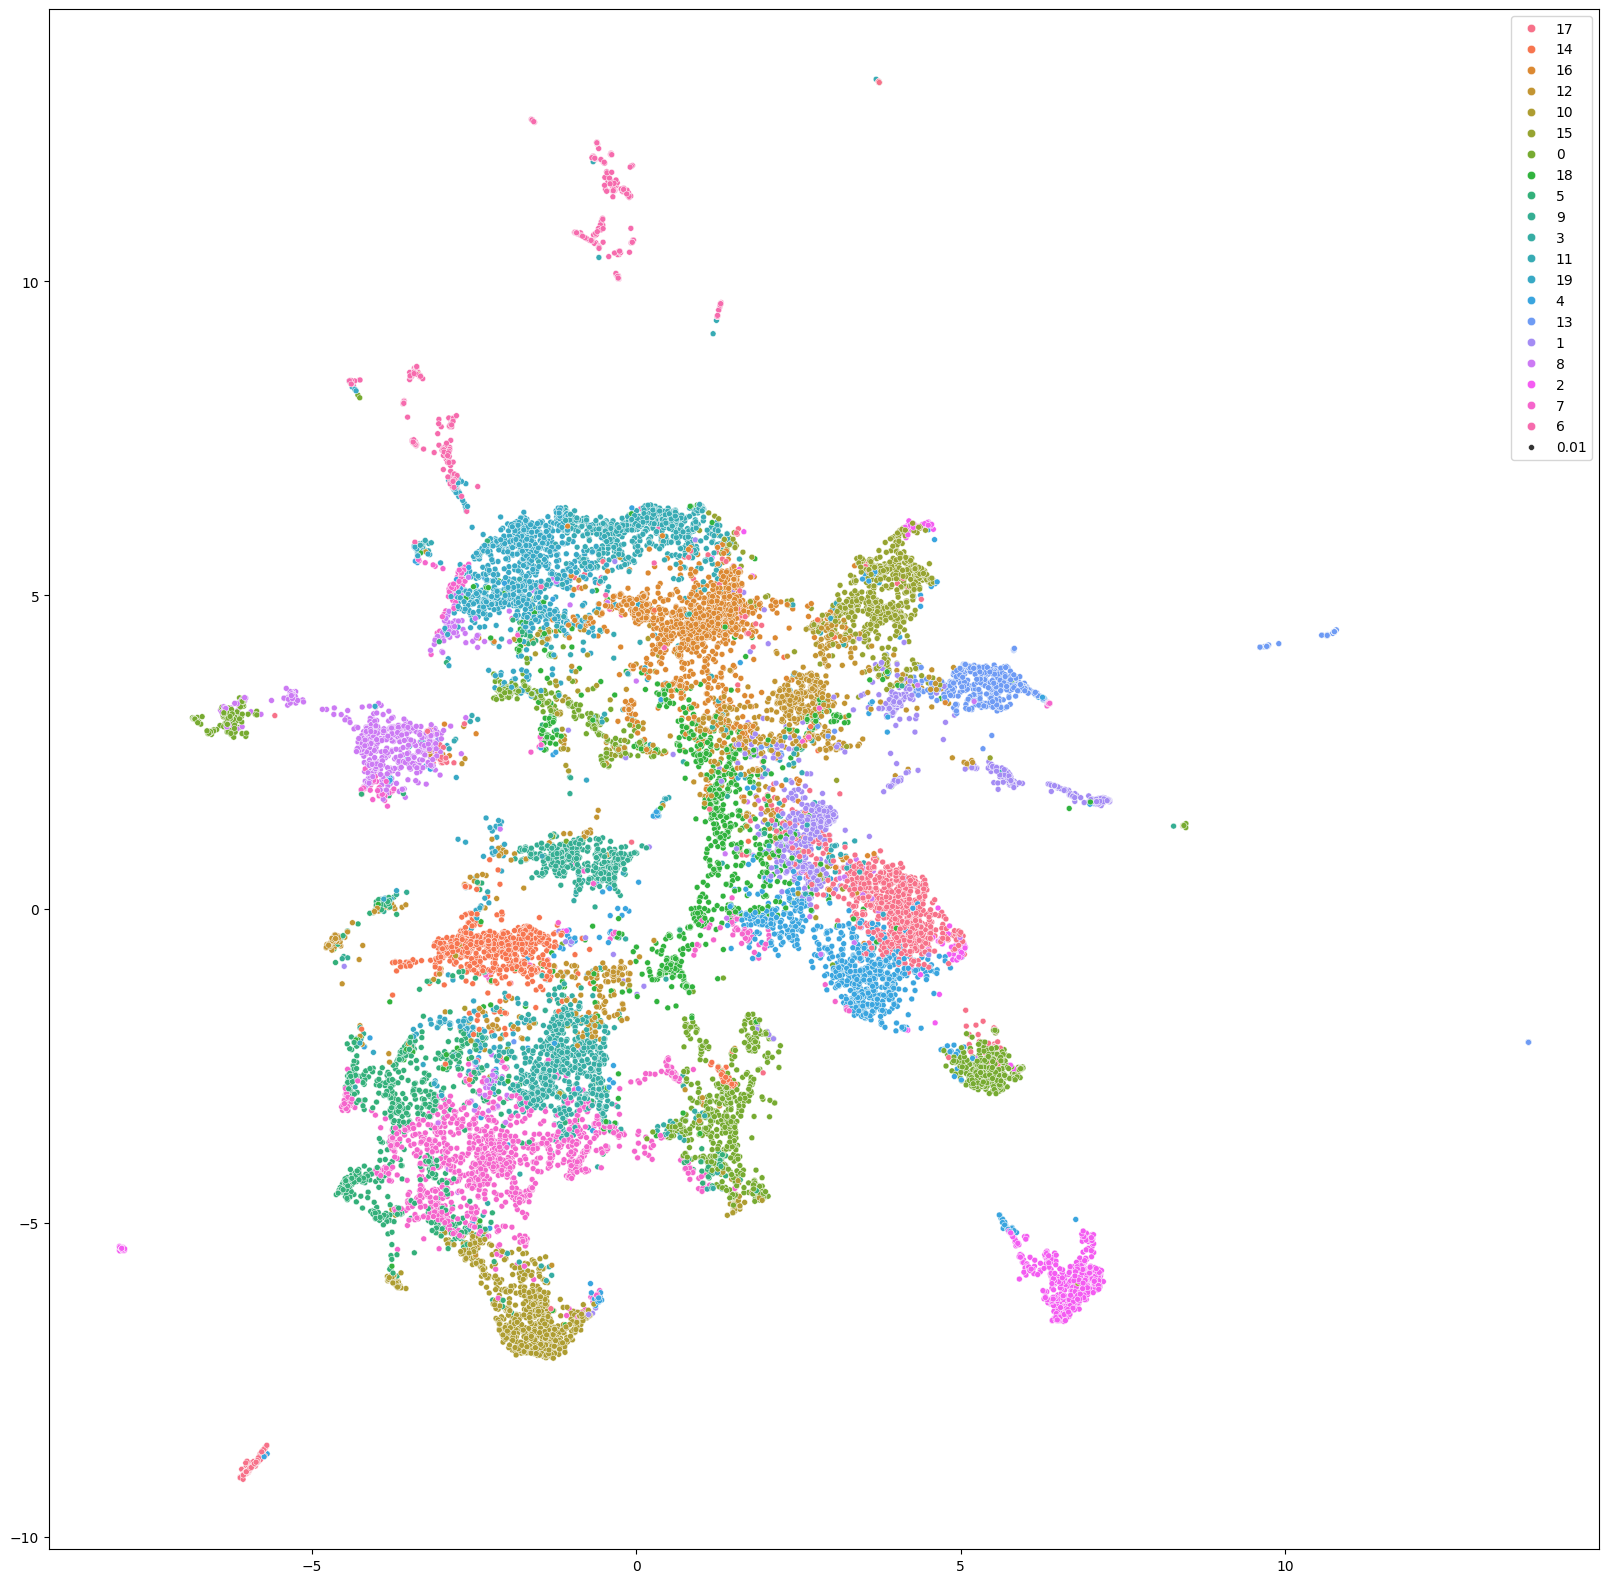

In [ ]:
import seaborn as sns

plt.figure(figsize=(20, 20))
sns.scatterplot(x = features_umap[:, 0],
                y = features_umap[:, 1],
                hue = cluster_labels.astype(str),
                size = 0.01)

plt.show()

In [48]:
# 分析每个聚类中出现最多的词
import pandas as pd
import numpy as np
import os
from collections import Counter
import re
import string

# 定义文本预处理函数
def preprocess_text(text):
    """预处理文本：转小写、移除标点、分词"""
    if pd.isna(text) or text == "":
        return []
    # 转小写
    text = str(text).lower()
    # 移除标点符号
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    # 分词（按空格）
    words = text.split()
    # 过滤掉太短的词（少于2个字符）
    words = [w for w in words if len(w) >= 2]
    return words

# 定义停用词（常见的无意义词）
stop_words = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
    'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been',
    'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that',
    'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'what',
    'which', 'who', 'when', 'where', 'why', 'how', 'all', 'each', 'every',
    'some', 'any', 'no', 'not', 'more', 'most', 'very', 'just', 'only', 'video', 'shows', 'frame', 
    'style'
])

def filter_stop_words(words):
    """过滤停用词"""
    return [w for w in words if w not in stop_words]

n_clusters = OpenVidHD['cluster_labels'].nunique()
top_n_words = 10  # 显示每个聚类出现最多的前N个词

print("=" * 80)
print("各聚类中出现最多的词（Top 10）")
print("=" * 80)

cluster_word_stats = {}

for cluster_id in sorted(OpenVidHD['cluster_labels'].unique()):
    # 获取该聚类的所有caption
    cluster_captions = OpenVidHD[OpenVidHD['cluster_labels'] == cluster_id]['caption']
    cluster_size = len(cluster_captions)
    
    # 统计所有词
    all_words = []
    for caption in cluster_captions:
        words = preprocess_text(caption)
        words = filter_stop_words(words)
        all_words.extend(words)
    
    # 计算词频
    word_counts = Counter(all_words)
    
    # 获取出现最多的词
    top_words = word_counts.most_common(top_n_words)
    
    cluster_word_stats[cluster_id] = {
        'size': cluster_size,
        'top_words': top_words,
        'total_words': len(all_words),
        'unique_words': len(word_counts)
    }
    
    
print("\n" + "=" * 80)
print("保存结果到CSV...")

# 创建结果DataFrame
results = []
for cluster_id, stats in cluster_word_stats.items():
    for rank, (word, count) in enumerate(stats['top_words'], 1):
        percentage = (count / stats['total_words']) * 100 if stats['total_words'] > 0 else 0
        results.append({
            'cluster_id': cluster_id,
            'rank': rank,
            'word': word,
            'count': count,
            'percentage': percentage,
            'cluster_size': stats['size']
        })

results_df = pd.DataFrame(results)


各聚类中出现最多的词（Top 10）

保存结果到CSV...


In [55]:
OpenVidHD.to_csv("OpenVidHD_filtered.csv")

In [57]:
# MATLAB v7.3 文件需要使用 h5py 读取，而不是 scipy.io.loadmat
import h5py
import numpy as np

def load_mat_v73(filename):
    """
    读取 MATLAB v7.3 格式的 .mat 文件（HDF5 格式）
    
    Args:
        filename: .mat 文件路径
    
    Returns:
        dict: 包含所有变量的字典
    """
    data = {}
    with h5py.File(filename, 'r') as f:
        def extract_data(name, obj):
            if isinstance(obj, h5py.Dataset):
                # 读取数据集
                arr = np.array(obj)
                # 如果数据是引用，需要解析
                if arr.dtype == 'object':
                    # 处理字符串数组或引用
                    try:
                        # 尝试读取引用的数据
                        arr_list = []
                        for ref in arr.flatten():
                            if isinstance(ref, h5py.Reference):
                                arr_list.append(np.array(f[ref]))
                            else:
                                arr_list.append(ref)
                        if len(arr_list) == 1:
                            arr = arr_list[0]
                        else:
                            arr = np.array(arr_list).reshape(arr.shape)
                    except:
                        pass
                data[name] = arr
        
        f.visititems(extract_data)
    return data

# 读取 MATLAB v7.3 文件
mat_file_path = '/media/ubuntu/sda/visual_stimuli_pattern/pinglei_bao_nature/img_array_obj19606_original.mat'
a = load_mat_v73(mat_file_path)

# 显示加载的变量（跳过 MATLAB 的元数据键，通常以 # 开头）
print("加载的变量:")
for key in a.keys():
    if not key.startswith('#'):  # 跳过 MATLAB 的元数据键
        val = a[key]
        if hasattr(val, 'shape'):
            print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
        else:
            print(f"  {key}: value={val}, type={type(val)}")

加载的变量:
  img_array: shape=(19606, 3, 224, 224), dtype=uint8


In [83]:
# 将图像转换为灰度图并保存为PNG格式
import os
from PIL import Image
from tqdm import tqdm

# 获取图像数据
img_array = a['img_array']  # shape: (19606, 3, 224, 224)
print(f"原始图像形状: {img_array.shape}")
print(f"数据类型: {img_array.dtype}")

# 创建输出目录
output_dir = '/media/ubuntu/sda/visual_stimuli_pattern/pinglei_bao_nature/image'
os.makedirs(output_dir, exist_ok=True)
print(f"输出目录: {output_dir}")

# 转换并保存图像
print(f"\n开始处理 {len(img_array)} 张图像...")
for i in tqdm(range(len(img_array)), desc="转换和保存图像"):
    # 获取单张图像 (3, 224, 224)
    img = img_array[i]
    
    # 转换维度顺序: (3, 224, 224) -> (224, 224, 3) for PIL
    img_rgb = np.transpose(img, (1, 2, 0))
    
    # 转换为PIL Image对象
    img_pil = Image.fromarray(img_rgb, mode='RGB')
    
    # 转换为灰度图
    img_gray = img_pil.convert('L')
    
    # 顺时针旋转90度
    img_gray = img_gray.rotate(-90, expand=True)  # 或者使用 img_gray.transpose(Image.ROTATE_90)
    
    # 保存为PNG格式
    output_path = os.path.join(output_dir, f'image_{i:05d}.png')
    img_gray.save(output_path, 'PNG')

print(f"\n✓ 完成! 已保存 {len(img_array)} 张灰度图像到: {output_dir}")


原始图像形状: (19606, 3, 224, 224)
数据类型: uint8
输出目录: /media/ubuntu/sda/visual_stimuli_pattern/pinglei_bao_nature/image

开始处理 19606 张图像...


转换和保存图像: 100%|██████████| 19606/19606 [02:23<00:00, 136.27it/s]


✓ 完成! 已保存 19606 张灰度图像到: /media/ubuntu/sda/visual_stimuli_pattern/pinglei_bao_nature/image
